# MDY'S REE PROJECT CODES

These codes serve for Doyeon's 2025 UROP Project. Its function is to aide in comparing each REE's elemental values, comparing different k values in REE speciations, checking which Ree speciations are included in the database and which else should be included.

Imports

In [62]:
import warnings
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import build_database.clean_tables as ct
import build_database.utils as ut
import utils
import importlib.resources as pkg_resources
import build_database.databases

Setup

In [63]:
# define REE elements
REE_elements = [
    'La', 'Ce', 'Pr', 'Nd', 'Pm', 'Sm', 'Eu',
    'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu',
    'Sc', 'Y'
]
# join the REE_elements so that I can use it in contains()
pattern = '|'.join(REE_elements)

# function for detecting REE elements in an equation
def contains_ree_elements(formula_string):
    # Returns True if any REE Elements are detected in an equation
    return any(ree in formula_string for ree in REE_elements)

In [64]:
# get databases folder from build_database
database_list = pkg_resources.files('build_database.databases')
database_list = ut.phreeqc_database_list(database_list)

# create Solution Species table for REES
solution_reespecies = ct.compile_solution_species_table(database_list)
solution_reespecies = solution_reespecies[solution_reespecies['equation'].str.contains(pattern, na=False)]

# create Solution Master Species table for REES
smsree = ct.compile_master_solution_table(database_list, analysis=True)
smsree = smsree[smsree['element'].isin(REE_elements)]

# drop duplicate rows
before = len(smsree)
filter_columns = ['element','species','alk','element_gfw']
smsree = smsree.drop_duplicates(subset=filter_columns)
after = len(smsree)
print(f'Filtered {before - after} duplicate rows from Solution Master Species table')
before = len(solution_reespecies)
filter_columns = solution_reespecies.columns[:-1]
solution_species = solution_reespecies.drop_duplicates(subset=filter_columns)
after = len(solution_species)
print(f'Filtered {before - after} duplicate rows from Solution Species table')

Filtered 3 duplicate rows from Solution Master Species table
Filtered 0 duplicate rows from Solution Species table


In [65]:
display(solution_reespecies)

,equation,log_k,delta_h,gamma,d_w,v_m,millero,activity_water,add_logk,llnl_gamma,co2_llnl_gamma,erm_ddl,no_check,mole_balance,source
12,Ce+3 = Ce+3,0.00,"(0, kJ/mol)",None,None,None,None,None,None,9.0,None,None,False,None,llnl.dat
18,Dy+3 = Dy+3,0.00,"(0, kJ/mol)",None,None,None,None,None,None,5.0,None,None,False,None,llnl.dat
20,Er+3 = Er+3,0.00,"(0, kJ/mol)",None,None,None,None,None,None,5.0,None,None,False,None,llnl.dat
22,Eu+3 = Eu+3,0.00,"(0, kJ/mol)",None,None,None,None,None,None,5.0,None,None,False,None,llnl.dat
26,Gd+3 = Gd+3,0.00,"(0, kJ/mol)",None,None,None,None,None,None,5.0,None,None,False,None,llnl.dat
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4098,1Sm+3 + 1Br- = SmBr+2,0.23,"(17.023,)",None,None,None,None,None,None,NaN,None,None,False,None,sit.dat
4099,1Sm+3 + 1Cl- = SmCl+2,0.72,"(22.277,)",None,None,None,None,None,None,NaN,None,None,False,None,sit.dat
4100,1Sm+3 + 1F- = SmF+2,4.21,"(24.180,)",None,None,None,None,None,None,NaN,None,None,False,None,sit.dat
4101,1Sm+3 + 2F- = SmF2+,6.43,"(18.850,)",None,None,None,None,None,None,NaN,None,None,False,None,sit.dat


In [66]:
display(smsree)

,element,species,alk,gfw_formula,element_gfw,source
41,Ce,Ce+3,0.0,Ce,140.115,#llnl.dat
63,Dy,Dy+3,0.0,Dy,162.50,#llnl.dat
67,Er,Er+3,0.0,Er,167.26,#llnl.dat
71,Eu,Eu+3,0.0,Eu,151.965,#llnl.dat
79,Gd,Gd+3,0.0,Gd,157.25,#llnl.dat
91,Ho,Ho+3,0.0,Ho,164.9303,#llnl.dat
104,La,La+3,0.0,La,138.9055,#llnl.dat
108,Lu,Lu+3,0.0,Lu,174.967,#llnl.dat
123,Nd,Nd+3,0.0,Nd,144.24,#llnl.dat
144,Pm,Pm+3,0.0,Pm,147.00,#llnl.dat


Datasource that contains the most REE equations?

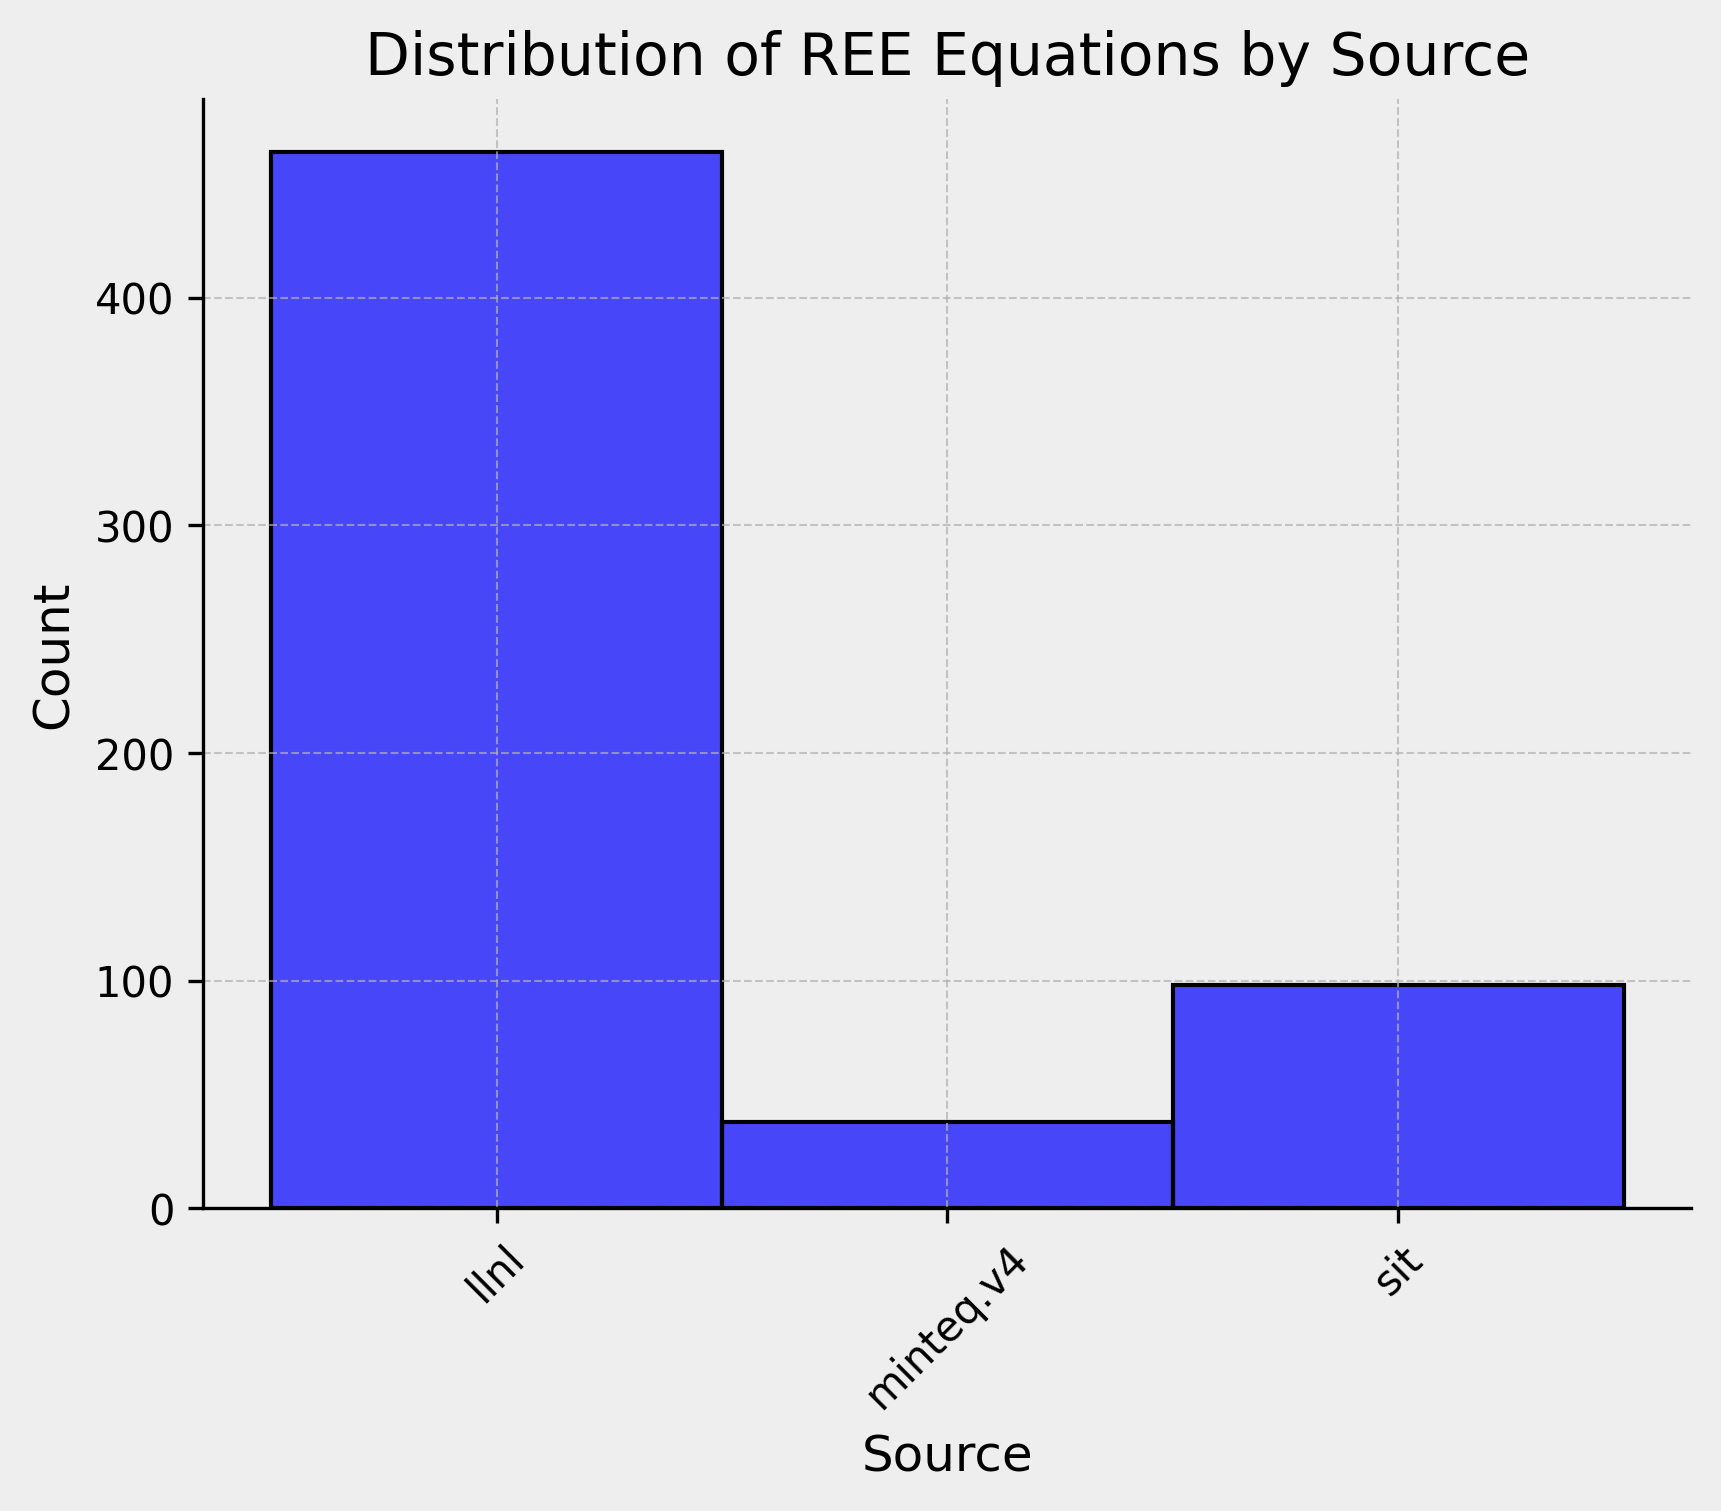

In [67]:
utils.plot_source_hist(solution_reespecies,'Distribution of REE Equations by Source')

How many equations have conflicting log k values?

In [68]:
(solution_reespecies.groupby('equation').nunique() > 1).sum()

log_k             0
delta_h           0
gamma             0
d_w               0
v_m               0
millero           0
activity_water    0
add_logk          0
llnl_gamma        0
co2_llnl_gamma    0
erm_ddl           0
no_check          0
mole_balance      0
source            0
dtype: int64

Do REE species have gram formula weight conflicts?

In [69]:
gfw_dups_number, gfw_dups_df = utils.alk_gfw_duplicates(smsree, 'element_gfw')
gfw_dups_df = gfw_dups_df.dropna(subset=['element_gfw'])
# convert to float
# gfw_dups_df['element_gfw'] = gfw_dups_df['element_gfw'].astype(float)
gfw_dups_df['element_gfw'] = pd.to_numeric(gfw_dups_df['element_gfw'], errors='coerce')
print(f"{gfw_dups_number} elements defined with different gfw attributes")
gfw_dups_df.head()

0 elements defined with different gfw attributes


,element,species,element_gfw,source
